# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


# Load CSV Dataset

In [2]:
# Load the CSV file
df = pd.read_csv(r"C:\Users\Sunrise Computer\Downloads\creditcard_fraud.csv")

print("✅ Data loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\nFirst 3 rows:")
print(df.head(3))
print("\nColumn names:")
print(df.columns.tolist())

✅ Data loaded successfully!
Shape: 93,949 rows × 31 columns

First 3 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   

        V26       V27       V28  Amount  Class  
0 -0.189115  0.133558 -0.021053  149.62    0.0  
1  0.125895 -0.008983  0.014724    2.69    0.0  
2 -0.139097 -0.055353 -0.059752  378.66    0.0  

[3 rows x 31 columns]

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 

# Keep Only Numeric Columns

In [3]:
# Keep only numeric columns - this prevents all string errors
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df = df[numeric_cols].copy()

print(f"✅ Using only numeric columns: {len(numeric_cols)} columns")
print(f"New shape: {df.shape}")
print("\nColumns being used:")
print(df.columns.tolist())

✅ Using only numeric columns: 31 columns
New shape: (93949, 31)

Columns being used:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


# Data Information

In [4]:
print("="*60)
print("DATA INFORMATION")
print("="*60)
print(df.info())

print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)
print(df.describe().round(2))

print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
print(df.isnull().sum())

DATA INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93949 entries, 0 to 93948
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    93949 non-null  int64  
 1   V1      93949 non-null  float64
 2   V2      93949 non-null  float64
 3   V3      93949 non-null  float64
 4   V4      93949 non-null  float64
 5   V5      93949 non-null  float64
 6   V6      93949 non-null  float64
 7   V7      93949 non-null  float64
 8   V8      93948 non-null  float64
 9   V9      93948 non-null  float64
 10  V10     93948 non-null  float64
 11  V11     93948 non-null  float64
 12  V12     93948 non-null  float64
 13  V13     93948 non-null  float64
 14  V14     93948 non-null  float64
 15  V15     93948 non-null  float64
 16  V16     93948 non-null  float64
 17  V17     93948 non-null  float64
 18  V18     93948 non-null  float64
 19  V19     93948 non-null  float64
 20  V20     93948 non-null  float64
 21  V21     93948 non-

# Target Variable Check

In [5]:
print("="*60)
print("TARGET VARIABLE CHECK")
print("="*60)

if 'Class' in df.columns:
    print(f"Target column: 'Class'")
    print(df['Class'].value_counts())
    print(f"\nFraud rate: {df['Class'].mean():.4%}")
elif 'DEFAULT' in df.columns:
    print(f"Target column: 'DEFAULT'")
    print(df['DEFAULT'].value_counts())
    print(f"\nDefault rate: {df['DEFAULT'].mean():.2%}")
else:
    print("ℹ️ No target column found. We'll use the last column for practice.")
    target_col = df.columns[-1]
    print(f"Using '{target_col}' as target")

TARGET VARIABLE CHECK
Target column: 'Class'
Class
0.0    93732
1.0      216
Name: count, dtype: int64

Fraud rate: 0.2299%


# Introduce Missing Data

In [6]:
np.random.seed(42)
df_missing = df.copy()

# Select columns for missing data (skip target columns)
all_cols = df.columns.tolist()
skip_cols = ['Class', 'DEFAULT']
cols_to_corrupt = [col for col in all_cols if col not in skip_cols][:3]

print(f"Adding 15% missing values to: {cols_to_corrupt}")

for col in cols_to_corrupt:
    mask = np.random.random(len(df)) < 0.15
    df_missing.loc[mask, col] = np.nan

print("\n🔴 Missing data introduced!")
for col in cols_to_corrupt:
    missing_pct = df_missing[col].isnull().mean()
    print(f"  {col:15s}: {missing_pct:.1%} missing")

Adding 15% missing values to: ['Time', 'V1', 'V2']

🔴 Missing data introduced!
  Time           : 15.0% missing
  V1             : 14.9% missing
  V2             : 14.9% missing


# Median Imputation

In [7]:
df_median = df_missing.copy()

for col in cols_to_corrupt:
    median_val = df_median[col].median()
    df_median[col].fillna(median_val, inplace=True)

print("✅ Median imputation complete!")
print(f"  Missing values after median: {df_median.isnull().sum().sum()}")

✅ Median imputation complete!
  Missing values after median: 23


# KNN Imputation

In [8]:
# Get columns for KNN
knn_cols = df_missing.select_dtypes(include=[np.number]).columns.tolist()
for col in ['Class', 'DEFAULT']:
    if col in knn_cols:
        knn_cols.remove(col)

# Take first 10 columns
knn_cols = knn_cols[:10]

print(f"Using {len(knn_cols)} columns for KNN imputation")

# Prepare data
df_knn_data = df_missing[knn_cols].copy()

# Fill any missing with median first
for col in knn_cols:
    if df_knn_data[col].isnull().sum() > 0:
        df_knn_data[col].fillna(df_knn_data[col].median(), inplace=True)

# Apply KNN
imputer = KNNImputer(n_neighbors=5)
df_knn_imputed = imputer.fit_transform(df_knn_data)

df_knn = df_missing.copy()
df_knn[knn_cols] = df_knn_imputed

print("✅ KNN imputation complete!")
print(f"  Missing values after KNN: {df_knn.isnull().sum().sum()}")

Using 10 columns for KNN imputation
✅ KNN imputation complete!
  Missing values after KNN: 21


# Compare Methods

In [9]:
print("="*60)
print("IMPUTATION COMPARISON")
print("="*60)

comparison = pd.DataFrame({
    'Feature': cols_to_corrupt,
    'Original_Var': [df[col].var() for col in cols_to_corrupt],
    'Median_Var': [df_median[col].var() for col in cols_to_corrupt],
    'KNN_Var': [df_knn[col].var() for col in cols_to_corrupt]
})

print(comparison.round(2))

print("\n" + "="*60)
print("VARIANCE PRESERVATION")
print("="*60)

median_pct = (comparison['Median_Var'] / comparison['Original_Var']).mean() * 100
knn_pct = (comparison['KNN_Var'] / comparison['Original_Var']).mean() * 100

print(f"Median: {median_pct:.1f}% variance preserved")
print(f"KNN:    {knn_pct:.1f}% variance preserved")

# Choose best method
if knn_pct >= median_pct:
    df_clean = df_knn.copy()
    print("\n✅ Using KNN imputation (better variance preservation)")
else:
    df_clean = df_median.copy()
    print("\n✅ Using Median imputation (better variance preservation)")

IMPUTATION COMPARISON
  Feature  Original_Var    Median_Var       KNN_Var
0    Time  2.710921e+08  2.304421e+08  2.304421e+08
1      V1  3.490000e+00  2.960000e+00  2.960000e+00
2      V2  2.770000e+00  2.400000e+00  2.400000e+00

VARIANCE PRESERVATION
Median: 85.4% variance preserved
KNN:    85.4% variance preserved

✅ Using KNN imputation (better variance preservation)


# Outlier Detection

In [10]:
def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return lower, upper, len(outliers), len(outliers)/len(df)*100

print("="*60)
print("OUTLIER DETECTION (IQR Method)")
print("="*60)

# Select columns to check
check_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
for col in ['Class', 'DEFAULT']:
    if col in check_cols:
        check_cols.remove(col)
check_cols = check_cols[:5]

for col in check_cols:
    lower, upper, count, pct = detect_outliers(df_clean, col)
    print(f"{col:15s}: {count:5d} outliers ({pct:.1f}%)")

OUTLIER DETECTION (IQR Method)
Time           :  5750 outliers (6.1%)
V1             :  2647 outliers (2.8%)
V2             :  6653 outliers (7.1%)
V3             :  3007 outliers (3.2%)
V4             :  1109 outliers (1.2%)


#  Winsorization

In [11]:
df_winsor = df_clean.copy()

print("="*60)
print("WINSORIZATION (Capping Outliers)")
print("="*60)

for col in check_cols:
    Q1 = df_winsor[col].quantile(0.25)
    Q3 = df_winsor[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_winsor[col] = df_winsor[col].clip(lower=lower, upper=upper)
    print(f"✅ Capped {col}")

print(f"\nShape after Winsorization: {df_winsor.shape} (100% rows preserved)")

WINSORIZATION (Capping Outliers)
✅ Capped Time
✅ Capped V1
✅ Capped V2
✅ Capped V3
✅ Capped V4

Shape after Winsorization: (93949, 31) (100% rows preserved)


# Feature Engineering

In [12]:
print("="*60)
print("FEATURE ENGINEERING")
print("="*60)

feature_count = 0

# Feature 1: Log Amount
if 'Amount' in df_winsor.columns:
    df_winsor['LOG_AMOUNT'] = np.log1p(df_winsor['Amount'])
    print("✅ Feature 1: LOG_AMOUNT")
    feature_count += 1

# Feature 2: Hour from Time
if 'Time' in df_winsor.columns:
    df_winsor['HOUR_OF_DAY'] = (df_winsor['Time'] / 3600) % 24
    print("✅ Feature 2: HOUR_OF_DAY")
    feature_count += 1

# Feature 3: V_MEAN
v_cols = [col for col in df_winsor.columns if col.startswith('V')]
if len(v_cols) >= 3:
    df_winsor['V_MEAN'] = df_winsor[v_cols[:3]].mean(axis=1)
    print("✅ Feature 3: V_MEAN")
    feature_count += 1

# Feature 4: V_SUM
if len(v_cols) >= 3:
    df_winsor['V_SUM'] = df_winsor[v_cols[:3]].sum(axis=1)
    print("✅ Feature 4: V_SUM")
    feature_count += 1

print(f"\nTotal new features created: {feature_count}")
print(f"Final shape: {df_winsor.shape}")

FEATURE ENGINEERING
✅ Feature 1: LOG_AMOUNT
✅ Feature 2: HOUR_OF_DAY
✅ Feature 3: V_MEAN
✅ Feature 4: V_SUM

Total new features created: 4
Final shape: (93949, 35)


# Visualizations

In [13]:
import os
print("✅ os module imported successfully!")
print(f"Current working directory: {os.getcwd()}")

✅ os module imported successfully!
Current working directory: C:\Users\Sunrise Computer\Downloads


CREATING AND SAVING VISUALIZATIONS
Found 34 columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'LOG_AMOUNT', 'HOUR_OF_DAY', 'V_MEAN', 'V_SUM']
✅ Saved


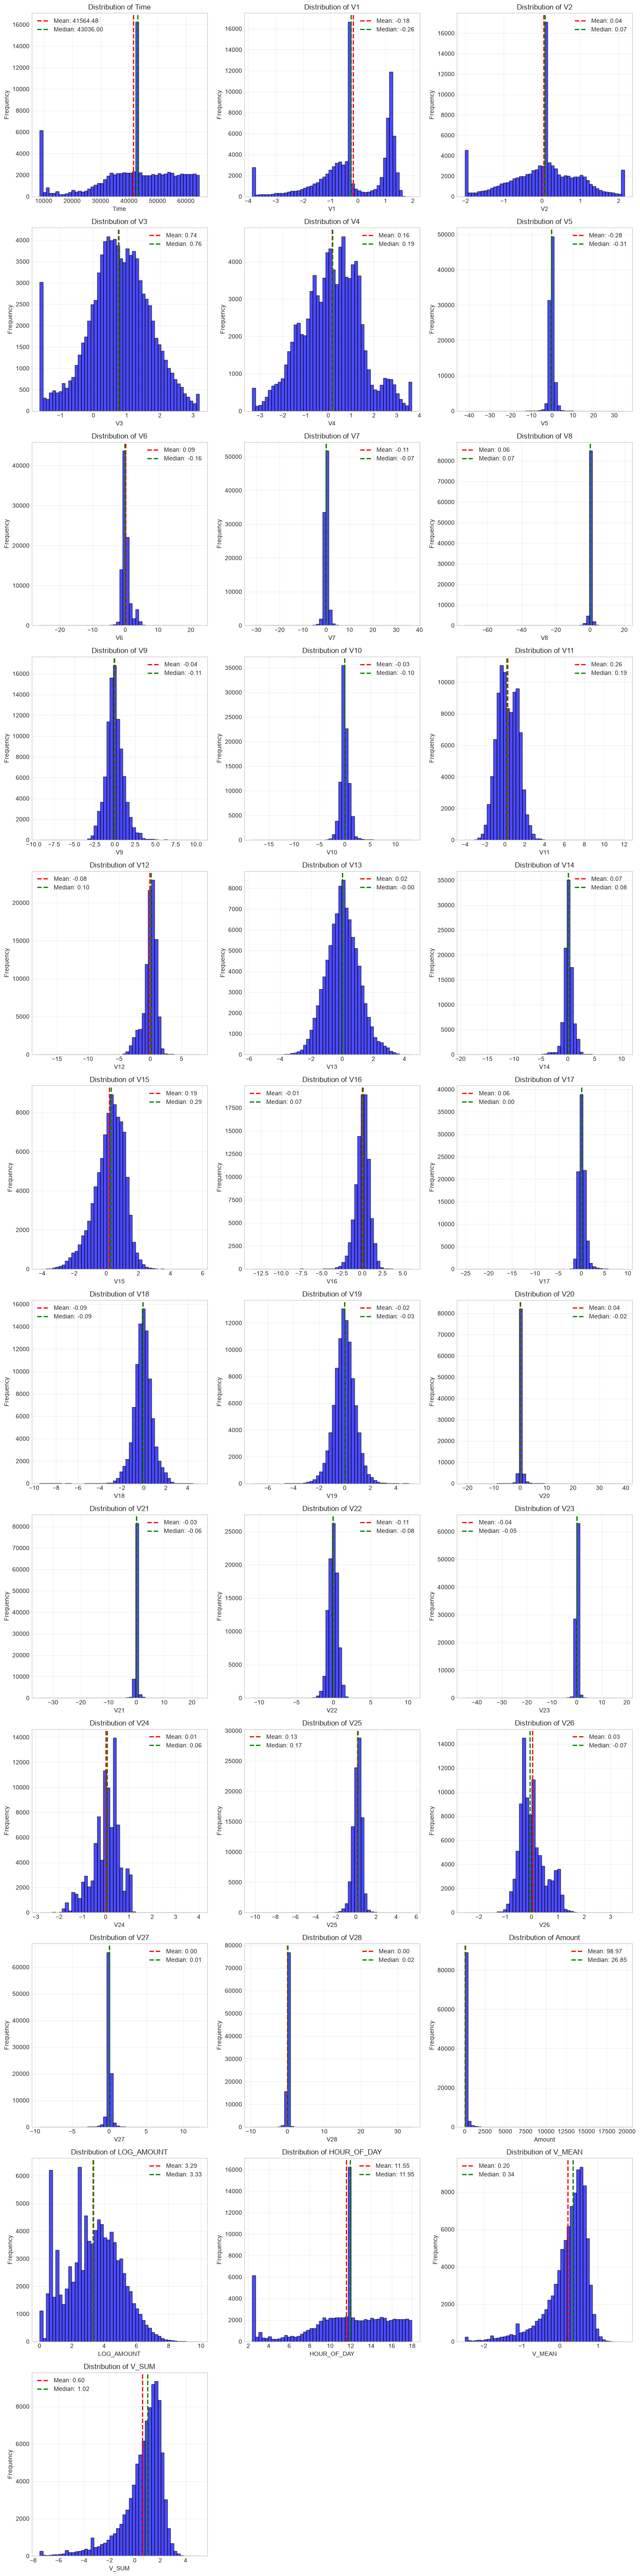


✅ Visualization complete!


In [14]:
print("="*60)
print("CREATING AND SAVING VISUALIZATIONS")
print("="*60)

numeric_cols = df_winsor.select_dtypes(include=[np.number]).columns.tolist()
for col in ['Class', 'DEFAULT']:
    if col in numeric_cols:
        numeric_cols.remove(col)

plot_cols = [c for c in numeric_cols if df_winsor[c].count() > 0]

print(f"Found {len(plot_cols)} columns: {plot_cols}")

# Create ONLY as many subplots as we have columns
n_cols = len(plot_cols)
n_rows = (n_cols + 2) // 3 # 3 per row
fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_cols > 1 else [axes]

for i, col in enumerate(plot_cols):
    data = df_winsor[col].dropna()
    axes[i].hist(data, bins=50, alpha=0.7, color='blue', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(alpha=0.3)
    axes[i].axvline(data.mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {data.mean():.2f}')
    axes[i].axvline(data.median(), color='green', linestyle='dashed', linewidth=2, label=f'Median: {data.median():.2f}')
    axes[i].legend()

# Hide unused subplots
for j in range(n_cols, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship/outputs/distributions.png', dpi=300, bbox_inches='tight')
print("✅ Saved")
plt.show()
print("\n✅ Visualization complete!")

# Saving Work

In [15]:
print("="*60)
print("EXPORTING YOUR WORK TO CORRECT PATHS")
print("="*60)

import os

# YOUR CORRECT PATHS
base_path = 'C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship'
data_path = base_path + '/data'
outputs_path = base_path + '/outputs'

# Create folders if they don't exist
if not os.path.exists(data_path):
    os.makedirs(data_path)
    print(f"✅ Created: {data_path}")

if not os.path.exists(outputs_path):
    os.makedirs(outputs_path)
    print(f"✅ Created: {outputs_path}")

# 1. Save cleaned data
df_winsor.to_csv(data_path + '/cleaned_credit_data.csv', index=False)
print(f"✅ Saved: {data_path}/cleaned_credit_data.csv")

# 2. Save column information
columns_info = pd.DataFrame({
    'Column': df_winsor.columns,
    'Data_Type': df_winsor.dtypes.values,
    'Non_Null': df_winsor.notnull().sum().values,
    'Unique': df_winsor.nunique().values
})
columns_info.to_csv(outputs_path + '/column_info.csv', index=False)
print(f"✅ Saved: {outputs_path}/column_info.csv")

print("\n" + "="*60)
print("📁 FILES SAVED TO:")
print("="*60)
print(f"📊 Data:     {data_path}/cleaned_credit_data.csv")
print(f"📋 Info:     {outputs_path}/column_info.csv")

EXPORTING YOUR WORK TO CORRECT PATHS
✅ Saved: C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship/data/cleaned_credit_data.csv
✅ Saved: C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship/outputs/column_info.csv

📁 FILES SAVED TO:
📊 Data:     C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship/data/cleaned_credit_data.csv
📋 Info:     C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship/outputs/column_info.csv


# Verifying all files exist

In [16]:
import os

print("="*60)
print("VERIFYING SAVED FILES")
print("="*60)

# YOUR CORRECT PATHS
base_path = 'C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship'
data_path = base_path + '/data'
outputs_path = base_path + '/outputs'

files_to_check = [
    (data_path + '/cleaned_credit_data.csv', 'Cleaned Data'),
    (outputs_path + '/column_info.csv', 'Column Information'),
    (outputs_path + '/distributions.png', 'Main Visualization')
]

all_exist = True
for file_path, description in files_to_check:
    if os.path.exists(file_path):
        size = os.path.getsize(file_path) / 1024
        if file_path.endswith('.csv'):
            import pandas as pd
            df_check = pd.read_csv(file_path)
            print(f"✅ {description}: {file_path} ({len(df_check):,} rows, {size:.1f} KB)")
        else:
            print(f"✅ {description}: {file_path} ({size:.1f} KB)")
    else:
        print(f"❌ {description}: {file_path} - NOT FOUND")
        all_exist = False

if all_exist:
    print("\n" + "="*60)
    print("🎉 ALL FILES ARE READY!")
    print("="*60)
else:
    print("\n⚠️ Some files are missing. Run STEP 1 first.")

VERIFYING SAVED FILES
✅ Cleaned Data: C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship/data/cleaned_credit_data.csv (93,949 rows, 39916.8 KB)
✅ Column Information: C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship/outputs/column_info.csv (35 rows, 0.9 KB)
✅ Main Visualization: C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship/outputs/distributions.png (2033.4 KB)

🎉 ALL FILES ARE READY!
